In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

clean = pd.read_csv("../data/retail_clean.csv", parse_dates=["InvoiceDate"])
daily = clean.set_index("InvoiceDate")["Revenue"].resample("D").sum().reset_index()
daily.columns = ["ds", "y"]
daily = daily[daily["y"] > 0]                      # trading days only
daily = daily[daily["ds"] < "2011-12-01"]          # drop partial Dec 2011

train = daily[daily["ds"] < "2011-06-01"]
print(len(train), "training days:", train["ds"].min().date(), "->", train["ds"].max().date())

Importing plotly failed. Interactive plots will not work.
C:\Users\Piyush\AppData\Local\Temp\ipykernel_17152\4046181764.py:6: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  clean = pd.read_csv("../data/retail_clean.csv", parse_dates=["InvoiceDate"])


440 training days: 2009-12-01 -> 2011-05-31


In [2]:
m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
            daily_seasonality=False, seasonality_mode="multiplicative")
m.fit(train)

d:\PROJECT\retail sales forecasting and customer segmentation project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
02:49:10 - cmdstanpy - INFO - Chain [1] start processing
02:49:11 - cmdstanpy - INFO - Chain [1] done processing


In [3]:
future = pd.DataFrame({"ds": pd.date_range("2011-06-01", "2011-11-30")})
fc = m.predict(future)[["ds", "yhat"]]
fc.loc[fc["ds"].dt.dayofweek == 5, "yhat"] = 0     # no Saturday sales
fc["yhat"] = fc["yhat"].clip(lower=0)

prophet_monthly = fc.set_index("ds")["yhat"].resample("MS").sum()
prophet_monthly.round(0)

ds
2011-06-01     678302.0
2011-07-01     636168.0
2011-08-01     713415.0
2011-09-01     836270.0
2011-10-01    1118113.0
2011-11-01    1407883.0
Freq: MS, Name: yhat, dtype: float64

In [4]:
monthly = pd.read_csv("../data/monthly_revenue.csv", parse_dates=["Month"]).set_index("Month")["Revenue"]
test = monthly.iloc[-6:]
seasonal = pd.Series([monthly[d - pd.DateOffset(years=1)] for d in test.index], index=test.index)

def mae(y, p):  return (y - p).abs().mean()
def mape(y, p): return ((y - p).abs() / y).mean() * 100

results = pd.DataFrame({
    "MAE":    [mae(test, seasonal), mae(test, prophet_monthly)],
    "MAPE_%": [mape(test, seasonal), mape(test, prophet_monthly)],
}, index=["Seasonal naive", "Prophet"]).round(1)
results

,MAE,MAPE_%
Seasonal naive,56696.4,6.5
Prophet,64079.9,6.9


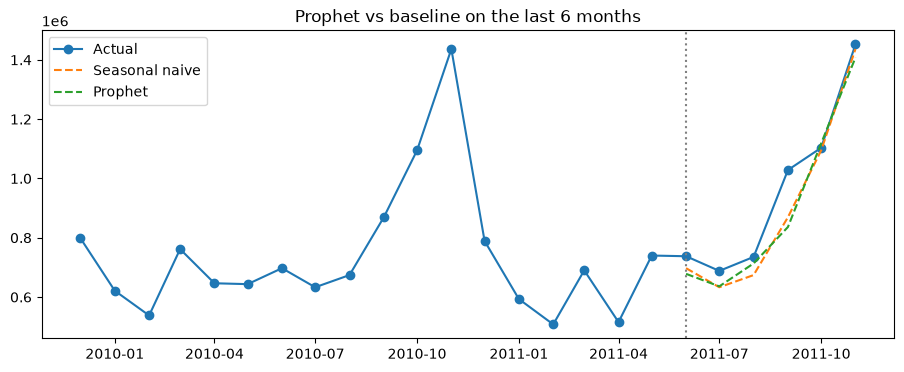

In [5]:
plt.figure(figsize=(11, 4))
plt.plot(monthly.index, monthly, label="Actual", marker="o")
plt.plot(test.index, seasonal, label="Seasonal naive", linestyle="--")
plt.plot(test.index, prophet_monthly, label="Prophet", linestyle="--")
plt.axvline(test.index[0], color="grey", linestyle=":")
plt.legend()
plt.title("Prophet vs baseline on the last 6 months")
plt.show()